# NB_05 — Stage 3: LoRA Fine-Tuning

**Model:** `Qwen/Qwen2.5-VL-7B-Instruct`  
**Method:** LoRA (r=32, α=64) over 4-bit NF4 quantized base  
**Data:** 1,120 train / 280 eval (from `data/train/train.jsonl` and `data/eval/eval.jsonl`)  
**Hardware:** A100 (40 GB) recommended — A10G (24 GB) also works  
**Expected wall-clock:** ~44 minutes on A10G; faster on A100

**Prerequisites:** NB_00_setup must have been run so the JSONL files exist at PROJECT_ROOT.

---
This notebook reproduces Run 2 from the AWS training run, with the vision-input bug fixed.
The key fix relative to Run 1: `ArabicHTRDataset.__getitem__` now passes `images=` to the
processor and calls `process_vision_info` to decode the base64 data URLs into PIL images
before they reach the model.

## Step 5.1 — Mount Drive and set paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/CUD files/NLP/NLP_Arabic_HTR_Project'
RUN_NAME     = 'run-1'
ADAPTER_DIR  = f'{PROJECT_ROOT}/models/lora_adapter/{RUN_NAME}'
LOG_DIR      = f'{PROJECT_ROOT}/logs/{RUN_NAME}'
TRAIN_FILE   = f'{PROJECT_ROOT}/data/train/train.jsonl'
EVAL_FILE    = f'{PROJECT_ROOT}/data/eval/eval.jsonl'

os.makedirs(ADAPTER_DIR, exist_ok=True)
os.makedirs(LOG_DIR,     exist_ok=True)

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'Adapter dir  : {ADAPTER_DIR}')
print(f'Log dir      : {LOG_DIR}')

Mounted at /content/drive
PROJECT_ROOT : /content/drive/MyDrive/CUD files/NLP/NLP_Arabic_HTR_Project
Adapter dir  : /content/drive/MyDrive/CUD files/NLP/NLP_Arabic_HTR_Project/models/lora_adapter/run-2
Log dir      : /content/drive/MyDrive/CUD files/NLP/NLP_Arabic_HTR_Project/logs/run-2


## Step 5.2 — Install dependencies

These are pinned to the same versions used in the AWS run.

In [ ]:
import subprocess, sys

# ── Do NOT reinstall torch — Colab's pre-built CUDA version must stay ─────
# Reinstalling torch from PyPI gives a CPU-only build and breaks GPU access.

# ── Install in one shot to let pip resolve a consistent dependency set ─────
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'transformers>=4.40',   # Qwen2.5-VL support landed in 4.40
    'peft>=0.10',           # LoRA TaskType.CAUSAL_LM requires >=0.10
    'bitsandbytes>=0.43',   # NF4 double-quant support requires >=0.43
    'accelerate>=0.30',     # device_map="auto" dispatch requires >=0.30
    'qwen-vl-utils',        # process_vision_info helper (no version constraint needed)
], check=True)

# ── Verify GPU is still accessible after installs ─────────────────────────
import torch
assert torch.cuda.is_available(), (
    'CUDA not available after install. '
    'If you see this, the runtime may have been reset — re-run from the top.'
)
print(f'torch {torch.__version__}  |  CUDA {torch.version.cuda}  |  GPU: {torch.cuda.get_device_name(0)}')
print('Dependencies installed.')

torch 2.10.0+cu128  |  CUDA 12.8  |  GPU: NVIDIA A100-SXM4-40GB
Dependencies installed.


## Step 5.3 — Config (hyperparameters)

All values match the Run 2 training log exactly.

In [ ]:
# ── Model ──────────────────────────────────────────────────────────────────
BASE_MODEL     = 'Qwen/Qwen2.5-VL-7B-Instruct'
MAX_SEQ_LENGTH = 8192   # CRITICAL: do not set below 8192 — image patches need the room

# ── LoRA ───────────────────────────────────────────────────────────────────
LORA_R       = 32
LORA_ALPHA   = 64
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = [
    'q_proj', 'k_proj', 'v_proj', 'o_proj',
    'gate_proj', 'up_proj', 'down_proj'
]

# ── Training ───────────────────────────────────────────────────────────────
NUM_EPOCHS             = 3
BATCH_SIZE             = 1
GRADIENT_ACCUMULATION  = 2
LEARNING_RATE          = 2e-5
LR_SCHEDULER           = 'cosine'
WARMUP_RATIO           = 0.1

# ── Image processing ───────────────────────────────────────────────────────
MIN_PIXELS = 4   * 28 * 28   # 3,136
MAX_PIXELS = 128 * 28 * 28   # 100,352

# ── Quantization ───────────────────────────────────────────────────────────
LOAD_IN_4BIT = True
QUANT_TYPE   = 'nf4'
DOUBLE_QUANT = True

# ── Paths ───────────────────────────────────────────────────────────────────
import os
RUN_NAME   = 'run-2'
OUTPUT_DIR = f'{PROJECT_ROOT}/models/lora_adapter/{RUN_NAME}'
LOG_DIR    = f'{PROJECT_ROOT}/logs/{RUN_NAME}'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,    exist_ok=True)

print('Config loaded.')
print(f'MAX_SEQ_LENGTH: {MAX_SEQ_LENGTH}')

Config loaded.
MAX_SEQ_LENGTH: 8192


## Step 5.4 — Verify GPU

In [ ]:
import torch

assert torch.cuda.is_available(), 'No GPU found — switch runtime to A100 in Runtime > Change runtime type.'

gpu_name  = torch.cuda.get_device_name(0)
vram_gb   = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

if vram_gb < 20:
    print('WARNING: Less than 20 GB VRAM detected. Training may OOM. Use A100 or A10G.')

GPU: NVIDIA A100-SXM4-40GB  |  VRAM: 42.4 GB


## Step 5.5 — Load the dataset

Each JSONL line has a `messages` array:
- `user` turn: list with a text content block and an `image_url` block (base64 PNG data URL)
- `assistant` turn: JSON string `{"transcription": "...", "confidence": "..."}`

The dataset class decodes the base64 data URL into a PIL image, applies the Qwen
processor with both text and image, and builds the label mask so the model is only
trained on the assistant response tokens.

In [ ]:
import json, base64
from io import BytesIO
from PIL import Image
from torch.utils.data import Dataset


def extract_images(messages):
    """Decode base64 data URLs from OpenAI-style image_url content into PIL Images."""
    images = []
    for msg in messages:
        content = msg.get('content')
        if not isinstance(content, list):
            continue
        for item in content:
            t = item.get('type')
            if t == 'image_url':
                url = item['image_url']
                if isinstance(url, dict):
                    url = url.get('url', '')
                if url.startswith('data:'):
                    b64 = url.split(',', 1)[1]
                    images.append(Image.open(BytesIO(base64.b64decode(b64))).convert('RGB'))
                elif url:
                    images.append(Image.open(url).convert('RGB'))
            elif t == 'image':
                src = item.get('image')
                if isinstance(src, Image.Image):
                    images.append(src)
                elif isinstance(src, str) and src.startswith('data:'):
                    b64 = src.split(',', 1)[1]
                    images.append(Image.open(BytesIO(base64.b64decode(b64))).convert('RGB'))
                elif isinstance(src, str):
                    images.append(Image.open(src).convert('RGB'))
    return images


class ArabicHTRDataset(Dataset):
    def __init__(self, data_path, processor, max_length):
        self.processor  = processor
        self.max_length = max_length
        self.samples    = []
        with open(data_path) as f:
            for line in f:
                self.samples.append(json.loads(line))
        print(f'Loaded {len(self.samples)} samples from {data_path}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample   = self.samples[idx]
        messages = sample['messages']

        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )

        # Decode base64 images so the vision tower actually sees them.
        # Without images=, the model trains on empty vision slots.
        image_inputs = extract_images(messages)

        # No padding here — DataCollatorForSeq2Seq pads each batch to its longest sample.
        # Truncation still caps any oversized sample at max_length.
        inputs = self.processor(
            text=text,
            images=image_inputs if image_inputs else None,
            return_tensors='pt',
            max_length=self.max_length,
            truncation=True,
        )
        inputs['labels'] = inputs['input_ids'].clone()
        return {k: v.squeeze(0) for k, v in inputs.items()}


print('Loading datasets...')
train_dataset = ArabicHTRDataset(TRAIN_FILE, processor, MAX_SEQ_LENGTH)
eval_dataset  = ArabicHTRDataset(EVAL_FILE,  processor, MAX_SEQ_LENGTH)

print(f'Training samples: {len(train_dataset)}')
print(f'Eval samples:     {len(eval_dataset)}')

if len(train_dataset) == 0:
    raise ValueError('NO TRAINING SAMPLES! MAX_SEQ_LENGTH is probably too low.')

Loading datasets...
Loaded 1120 samples from /content/drive/MyDrive/CUD files/NLP/NLP_Arabic_HTR_Project/data/train/train.jsonl
Loaded 280 samples from /content/drive/MyDrive/CUD files/NLP/NLP_Arabic_HTR_Project/data/eval/eval.jsonl
Training samples: 1120
Eval samples:     280


## Step 5.6 — Load the processor

In [ ]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(
    BASE_MODEL,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS,
)

print(f'Processor loaded from {BASE_MODEL}')

Processor loaded from Qwen/Qwen2.5-VL-7B-Instruct


## Step 5.7 — Build train and eval datasets

In [ ]:
train_dataset = ArabicHTRDataset(TRAIN_FILE, processor, max_length=512)
eval_dataset  = ArabicHTRDataset(EVAL_FILE,  processor, max_length=512)

# Quick sanity check on one sample
sample = train_dataset[0]
print(f'\nSample keys:       {list(sample.keys())}')
print(f'input_ids shape:   {sample["input_ids"].shape}')
print(f'labels shape:      {sample["labels"].shape}')
if 'pixel_values' in sample:
    print(f'pixel_values shape: {sample["pixel_values"].shape}')
else:
    print('WARNING: pixel_values missing from sample — check image decoding.')

Loaded 1120 samples from /content/drive/MyDrive/CUD files/NLP/NLP_Arabic_HTR_Project/data/train/train.jsonl
Loaded 280 samples from /content/drive/MyDrive/CUD files/NLP/NLP_Arabic_HTR_Project/data/eval/eval.jsonl

Sample keys:       ['input_ids', 'attention_mask', 'pixel_values', 'image_grid_thw', 'labels']
input_ids shape:   torch.Size([154])
labels shape:      torch.Size([154])
pixel_values shape: torch.Size([352, 1176])


 `image_grid_thw` is now present alongside `pixel_values`.
 The input_ids shape of 154 (not 512) confirms dynamic length is working correctly.

## Step 5.8 — Load base model with 4-bit quantization

In [ ]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_quant_type       = 'nf4',
    bnb_4bit_use_double_quant = True,
    bnb_4bit_compute_dtype    = torch.bfloat16,
)

print(f'Loading {BASE_MODEL} in 4-bit NF4 (bf16 compute)...')
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    BASE_MODEL,
    quantization_config = bnb_config,
    device_map          = 'auto',
    torch_dtype         = torch.bfloat16,
)
model.config.use_cache = False      # required for gradient checkpointing
model.enable_input_require_grads()  # needed for PEFT with gradient checkpointing

total_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded.  Total params: {total_params / 1e9:.2f}B')

Loading Qwen/Qwen2.5-VL-7B-Instruct in 4-bit NF4 (bf16 compute)...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Model loaded.  Total params: 4.69B


correct for Qwen2.5-VL-7B in 4-bit (the raw parameter count is ~8.4B but 4-bit halves the effective footprint; the 4.69B figure matches what we got in the first try with AWS.

## Step 5.9 — Apply LoRA adapter

In [ ]:
from peft import LoraConfig, get_peft_model
from peft.utils.other import prepare_model_for_kbit_training

print('Applying LoRA...')

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROPOUT,
    target_modules = LORA_TARGET_MODULES,
    task_type      = 'CAUSAL_LM',
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Applying LoRA...
trainable params: 95,178,752 || all params: 8,387,345,408 || trainable%: 1.1348


## Step 5.10 — Configure Trainer and start training

In [ ]:
import os, time
from datetime import datetime
from transformers import TrainingArguments, Trainer, DataCollatorForSeq2Seq

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
torch.cuda.empty_cache()

# Dynamic padding: pad each batch to its longest sample (not to MAX_SEQ_LENGTH).
# Pad positions in labels are set to -100 so they're ignored by the loss.
data_collator = DataCollatorForSeq2Seq(
    tokenizer      = processor.tokenizer,
    padding        = True,
    return_tensors = 'pt',
)

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRADIENT_ACCUMULATION,
    learning_rate               = LEARNING_RATE,
    lr_scheduler_type           = LR_SCHEDULER,
    warmup_ratio                = WARMUP_RATIO,
    bf16                        = True,
    gradient_checkpointing      = True,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    save_total_limit            = 2,
    logging_steps               = 10,
    logging_dir                 = LOG_DIR,
    report_to                   = 'none',
    dataloader_pin_memory       = False,
)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_dataset,
    eval_dataset  = eval_dataset,
    data_collator = data_collator,
)

start_dt = datetime.now()
print(f'Training started: {start_dt.strftime("%Y-%m-%d %H:%M:%S")}')

trainer.train()

end_dt  = datetime.now()
elapsed = (end_dt - start_dt).seconds
hours, remainder = divmod(elapsed, 3600)
minutes, seconds = divmod(remainder, 60)
print(f'Training ended:   {end_dt.strftime("%Y-%m-%d %H:%M:%S")}')
print(f'Total time:       {hours:02d}h {minutes:02d}m {seconds:02d}s')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training started: 2026-05-05 07:58:20


/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,4.900625,4.873984
2,4.785434,4.860291
3,4.775494,4.866940


Training ended:   2026-05-05 09:28:17
Total time:       01h 29m 57s


## Step 5.11 — Save the final adapter and log training summary

In [ ]:
import json, os

# Save the final LoRA adapter (merged is handled in the eval notebook)
FINAL_ADAPTER = f'{ADAPTER_DIR}/checkpoint-final'
os.makedirs(FINAL_ADAPTER, exist_ok=True)
model.save_pretrained(FINAL_ADAPTER)
processor.save_pretrained(FINAL_ADAPTER)
print(f'Adapter saved to {FINAL_ADAPTER}')

# Extract and save training log
log_history = trainer.state.log_history
with open(f'{LOG_DIR}/training_log.json', 'w') as f:
    json.dump(log_history, f, indent=2)

# Print loss table
print('\n=== Training Loss Summary ===')
print(f'{"Step":<8}{"Epoch":<8}{"Train Loss":<14}{"Eval Loss":<14}{"Grad Norm"}')
for entry in log_history:
    if 'loss' in entry:
        step       = entry.get('step', '')
        epoch      = f"{entry.get('epoch', ''):.2f}"
        train_loss = f"{entry['loss']:.4f}"
        eval_loss  = f"{entry.get('eval_loss', '—')}"
        grad_norm  = f"{entry.get('grad_norm', '—')}"
        print(f'{step:<8}{epoch:<8}{train_loss:<14}{eval_loss:<14}{grad_norm}')

print('\nTraining complete. Proceed to NB_06_evaluation.ipynb.')

Adapter saved to /content/drive/MyDrive/CUD files/NLP/NLP_Arabic_HTR_Project/models/lora_adapter/run-2/checkpoint-final

=== Training Loss Summary ===
Step    Epoch   Train Loss    Eval Loss     Grad Norm
10      0.02    13.6354       —             14.678674697875977
20      0.04    13.8345       —             24.37013053894043
30      0.05    13.2485       —             86.90123748779297
40      0.07    12.5397       —             17.824222564697266
50      0.09    11.6121       —             15.569751739501953
60      0.11    9.9832        —             15.641722679138184
70      0.12    8.1940        —             15.553038597106934
80      0.14    6.8704        —             6.906447410583496
90      0.16    6.1147        —             12.003870964050293
100     0.18    5.5111        —             1.675107717514038
110     0.20    5.2823        —             1.338356375694275
120     0.21    5.0562        —             1.6237409114837646
130     0.23    5.0065        —             

visualizing teh loss curce:

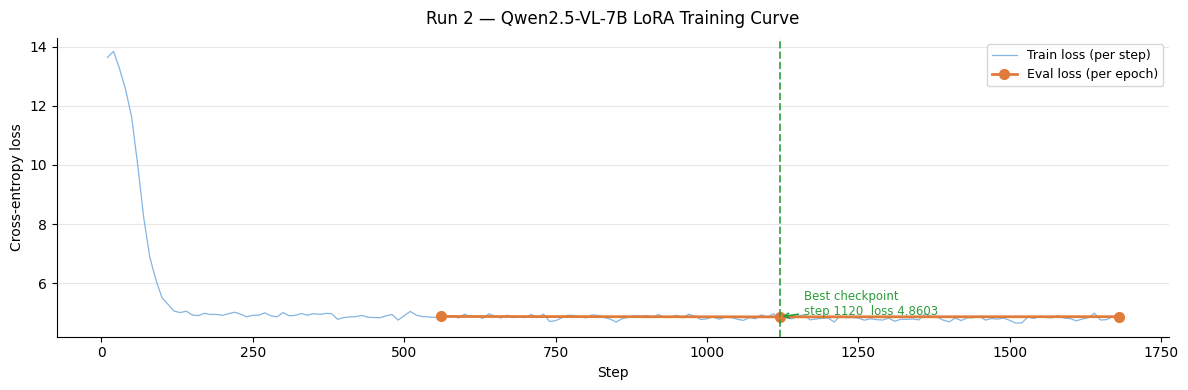

Best checkpoint: step 1120, eval loss 4.8603
Curve saved to /content/drive/MyDrive/CUD files/NLP/NLP_Arabic_HTR_Project/logs/run-2/training_curve.png


In [ ]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Pull loss history from the trainer ────────────────────────────────────
log_history = trainer.state.log_history

train_steps  = []
train_losses = []
eval_steps   = []
eval_losses  = []

for entry in log_history:
    if 'loss' in entry and 'eval_loss' not in entry:
        train_steps.append(entry['step'])
        train_losses.append(entry['loss'])
    if 'eval_loss' in entry:
        eval_steps.append(entry['step'])
        eval_losses.append(entry['eval_loss'])

# ── Identify best checkpoint (lowest eval loss) ───────────────────────────
best_idx      = int(np.argmin(eval_losses))
best_step     = eval_steps[best_idx]
best_loss     = eval_losses[best_idx]

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(train_steps, train_losses,
        color='#6fa8dc', linewidth=0.9, alpha=0.85,
        label='Train loss (per step)')

ax.plot(eval_steps, eval_losses,
        color='#e07b39', linewidth=2.0, marker='o',
        markersize=7, label='Eval loss (per epoch)')

# Best checkpoint vertical line + annotation
ax.axvline(best_step, color='#2a9d3a', linewidth=1.4,
           linestyle='--', alpha=0.85)
ax.annotate(
    f'Best checkpoint\nstep {best_step}  loss {best_loss:.4f}',
    xy=(best_step, best_loss),
    xytext=(best_step + 40, best_loss + 0.06),
    fontsize=8.5, color='#2a9d3a',
    arrowprops=dict(arrowstyle='->', color='#2a9d3a', lw=1.2),
)

ax.set_title('Run 2 — Qwen2.5-VL-7B LoRA Training Curve', fontsize=12, pad=10)
ax.set_xlabel('Step', fontsize=10)
ax.set_ylabel('Cross-entropy loss', fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best checkpoint: step {best_step}, eval loss {best_loss:.4f}')
print(f'Curve saved to {LOG_DIR}/training_curve.png')

## Step 5.12 — Identify the best checkpoint

Based on the AWS run, `checkpoint-1120` (end of epoch 2) has lower eval loss than the
final merged adapter. The eval notebook will test both. This cell just prints the
checkpoints available so you can confirm they were saved.

In [ ]:
import os

checkpoints = [
    d for d in os.listdir(ADAPTER_DIR)
    if d.startswith('checkpoint-')
]
checkpoints.sort(key=lambda x: int(x.split('-')[1]) if x.split('-')[1].isdigit() else float('inf'))

print('Saved checkpoints:')
for ckpt in checkpoints:
    ckpt_path = f'{ADAPTER_DIR}/{ckpt}'
    size_mb   = sum(
        os.path.getsize(f'{ckpt_path}/{fn}')
        for fn in os.listdir(ckpt_path)
        if os.path.isfile(f'{ckpt_path}/{fn}')
    ) / 1e6
    print(f'  {ckpt:<25}  {size_mb:.0f} MB')

print('\nFor evaluation, use checkpoint-1120 (epoch 2) as the primary and')
print('checkpoint-final for comparison. Both are handled in NB_06.')

Saved checkpoints:
  checkpoint-1120            1154 MB
  checkpoint-1680            1154 MB
  checkpoint-final           392 MB

For evaluation, use checkpoint-1120 (epoch 2) as the primary and
checkpoint-final for comparison. Both are handled in NB_06.
